# 03 — PhoBERT: извлечение признаков + нейросетевой классификатор

Конкурирующий подход на основе **предобученной трансформерной модели
[PhoBERT-base](https://huggingface.co/vinai/phobert-base)** (Nguyen & Nguyen, 2020) —
первой крупной монолингвальной языковой модели для вьетнамского языка.

Схема (feature extraction, как в работе-образце с DistilBERT):
1. Веса PhoBERT **заморожены** — модель используется как извлекатель признаков;
2. для каждого отзыва берётся вектор токена `[CLS]` (768 признаков);
3. поверх признаков обучается полносвязный классификатор (MLP, tanh).


In [1]:
# Установка зависимостей (на Kaggle нужен включённый интернет)
!pip install -q transformers underthesea

import os
import json
import re
import numpy as np
import pandas as pd
import torch
from torch import nn
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from underthesea import word_tokenize

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Устройство:', DEVICE)

# --- ПУТИ (настройте под свой датасет на Kaggle!) ---
DATA_PATH = '/kaggle/input/datasets/gnehttran/data-tiki-for-sentiment/data.csv'
OUTPUT_DIR = '/kaggle/working/artifacts'
RESULTS_DIR = '/kaggle/working/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 55.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.4 MB/s eta 0:00:0000:01
Устройство: cuda


## 1. Данные и предобработка (общий пайплайн проекта)

In [2]:
# ============================================================
# Предобрaботкa (идентичнa ноутбуку 01: очисткa + сегментaция + стоп-словa)
# ============================================================

def clean_text(text):
    """Бaзовaя очисткa вьетнaмского текстa отзывa."""
    if pd.isna(text):
        return ''
    text = str(text)
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[\+]?[1-9]?[0-9]{7,15}', '', text)
    text = re.sub(r'\d+', ' number_token ', text)  # числa -> токен до удaления спецсимволов
    text = re.sub(r'[^\w\s\u00C0-\u1EF9_]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

# Бaзовый список стоп-слов вьетнaмского языкa (+ словa доменa e-commerce)
vietnamese_stopwords = set([
    'tôi', 'mình', 'tao', 'mày', 'họ', 'nó', 'chúng', 'ta', 'chúng_tôi', 'chúng_ta',
    'bạn', 'anh', 'chị', 'em', 'cô', 'chú', 'bác', 'ông', 'bà',
    'và', 'với', 'của', 'trong', 'tại', 'ở', 'trên', 'dưới', 'cho', 'về',
    'là', 'có', 'được', 'bị', 'phải', 'đã', 'đang', 'sẽ', 'vẫn', 'còn',
    'như', 'nhưng', 'thì', 'mà', 'nếu', 'vì', 'do', 'nên',
    'rất', 'quá', 'lắm', 'cực', 'hơi', 'khá',
    'cái', 'chiếc', 'những', 'các', 'mọi', 'này', 'kia', 'đó',
    'ạ', 'nhé', 'à', 'ừ', 'vâng', 'dạ', 'thôi', 'rồi', 'nhỉ',
    'shop', 'tiki', 'shopee', 'lazada', 'sản_phẩm', 'mua', 'bán'
])

def remove_stopwords(text):
    """Сегментaция underthesea + удaление стоп-слов; состaвные словa склеивaются '_'."""
    words = word_tokenize(text)
    filtered = [w for w in words if w not in vietnamese_stopwords and len(w) > 1]
    return ' '.join(w.replace(' ', '_') for w in filtered)

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
df['content_cleaned'] = df['content'].apply(clean_text)
df['content_final'] = df['content_cleaned'].apply(remove_stopwords)
df = df[df['content_final'].str.split().str.len() >= 2]  # отбрaсывaем слишком короткие
print(f'Примеров после предобрaботки: {len(df):,} из {len(df_raw):,}')

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['lable'])
X = df['content_cleaned'].values  # для PhoBERT — очищенный текст БЕЗ склейки '_'
                                  # (у PhoBERT собственный BPE-токенизaтор)

# То же рaзбиение, что и в остaльных экспериментaх (80/20, seed=42, стрaтификaция)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Примеров после предобрaботки: 26,176 из 26,382
Train: 20,940 | Test: 5,236


## 2. Извлечение признаков PhoBERT

Веса модели заморожены (`requires_grad=False`): PhoBERT выступает
энкодером, обучается только классификаторная «голова».

In [3]:
PHOBERT = 'vinai/phobert-base'
tokenizer = AutoTokenizer.from_pretrained(PHOBERT)
phobert = AutoModel.from_pretrained(PHOBERT).to(DEVICE)
phobert.eval()
for p in phobert.parameters():
    p.requires_grad = False  # замораживаем энкодер

@torch.no_grad()
def extract_cls_features(texts, batch_size=32, max_len=256):
    """Возвращает CLS-векторы (N, 768) для списка текстов."""
    feats = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i + batch_size])
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=max_len, return_tensors='pt').to(DEVICE)
        out = phobert(**enc).last_hidden_state[:, 0, :]  # вектор [CLS]
        feats.append(out.cpu())
        if (i // batch_size) % 20 == 0:
            print(f'  обработано {i + len(batch):,}/{len(texts):,}')
    return torch.cat(feats).numpy()

X_train_f = extract_cls_features(X_train)
X_test_f = extract_cls_features(X_test)

# Сохраняем признаки, чтобы не пересчитывать их при подборе классификатора
feat_dir = os.path.join(OUTPUT_DIR, 'phobert_features')
os.makedirs(feat_dir, exist_ok=True)
np.save(os.path.join(feat_dir, 'X_train.npy'), X_train_f)
np.save(os.path.join(feat_dir, 'X_test.npy'), X_test_f)
np.save(os.path.join(feat_dir, 'y_train.npy'), y_train)
np.save(os.path.join(feat_dir, 'y_test.npy'), y_test)
print('Признаки сохранены:', X_train_f.shape, X_test_f.shape)

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  обработано 32/20,940
  обработано 672/20,940
  обработано 1,312/20,940
  обработано 1,952/20,940
  обработано 2,592/20,940
  обработано 3,232/20,940
  обработано 3,872/20,940
  обработано 4,512/20,940
  обработано 5,152/20,940
  обработано 5,792/20,940
  обработано 6,432/20,940
  обработано 7,072/20,940
  обработано 7,712/20,940
  обработано 8,352/20,940
  обработано 8,992/20,940
  обработано 9,632/20,940
  обработано 10,272/20,940
  обработано 10,912/20,940
  обработано 11,552/20,940
  обработано 12,192/20,940
  обработано 12,832/20,940
  обработано 13,472/20,940
  обработано 14,112/20,940
  обработано 14,752/20,940
  обработано 15,392/20,940
  обработано 16,032/20,940
  обработано 16,672/20,940
  обработано 17,312/20,940
  обработано 17,952/20,940
  обработано 18,592/20,940
  обработано 19,232/20,940
  обработано 19,872/20,940
  обработано 20,512/20,940
  обработано 32/5,236
  обработано 672/5,236
  обработано 1,312/5,236
  обработано 1,952/5,236
  обработано 2,592/5,236
  обработа

## 3. Классификатор поверх признаков PhoBERT

Архитектура — постепенное сужение числа нейронов (как в работе-образце):
256 -> 128 -> 64 -> 32 -> 6, активация tanh, dropout 0.1.

In [4]:
class ClassifierHead(nn.Module):
    """Полносвязный классификатор поверх CLS-признаков PhoBERT."""
    def __init__(self, in_dim=768, num_classes=6, dropout=0.1):
        super().__init__()
        blocks, dims = [], [256, 128, 64, 32]
        prev = in_dim
        for d in dims:  # блоки с постепенным уменьшением ширины
            blocks += [nn.Linear(prev, d), nn.Tanh()]
            if d in (128, 32):  # dropout после 2-го и 4-го блоков
                blocks += [nn.Dropout(dropout)]
            prev = d
        blocks += [nn.Linear(prev, num_classes)]
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x)

clf = ClassifierHead(num_classes=len(label_encoder.classes_)).to(DEVICE)
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

Xt = torch.tensor(X_train_f, dtype=torch.float32)
yt = torch.tensor(y_train, dtype=torch.long)
Xv = torch.tensor(X_test_f, dtype=torch.float32)

# Простой цикл обучения мини-батчами
EPOCHS, BS = 60, 256
for epoch in range(EPOCHS):
    clf.train()
    perm = torch.randperm(len(Xt))
    epoch_loss = 0.0
    for i in range(0, len(Xt), BS):
        idx = perm[i:i + BS]
        loss = criterion(clf(Xt[idx].to(DEVICE)), yt[idx].to(DEVICE))
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f'Эпоха {epoch + 1}/{EPOCHS}, loss={epoch_loss:.3f}')

Эпоха 10/60, loss=11.102
Эпоха 20/60, loss=7.214
Эпоха 30/60, loss=4.706
Эпоха 40/60, loss=2.807
Эпоха 50/60, loss=1.814
Эпоха 60/60, loss=3.564


## 4. Оценка качества

Accuracy: 0.9328
              precision    recall  f1-score   support

       anger     0.9258    0.9655    0.9452       956
     disgust     0.8654    0.8167    0.8403       551
        fear     0.9911    0.9955    0.9933       897
   happiness     0.8787    0.9516    0.9137       929
     sadness     0.9475    0.9248    0.9360       957
    surprise     0.9670    0.8975    0.9309       946

    accuracy                         0.9328      5236
   macro avg     0.9293    0.9253    0.9266      5236
weighted avg     0.9337    0.9328    0.9326      5236



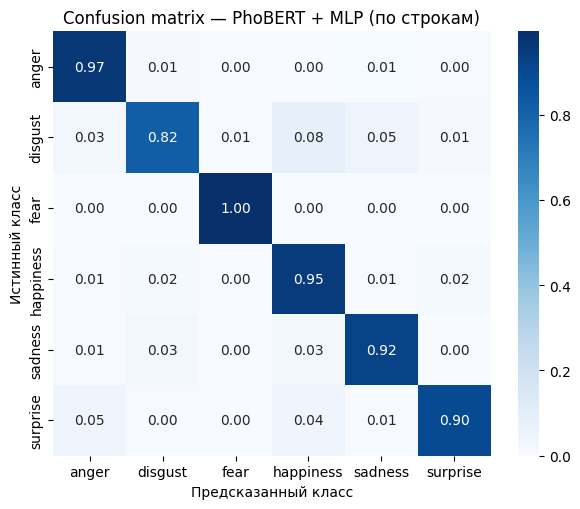

Классификатор сохранён: /kaggle/working/artifacts/phobert_classifier_head.pt
Метрики для отчёта сохранены: /kaggle/working/results/phobert_metrics.json


In [5]:
clf.eval()
with torch.no_grad():
    logits = clf(Xv.to(DEVICE))
pred = logits.argmax(dim=1).cpu().numpy()

print(f'Accuracy: {accuracy_score(y_test, pred):.4f}')
print(classification_report(y_test, pred, target_names=label_encoder.classes_, digits=4))

cm = confusion_matrix(y_test, pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6.2, 5.2))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion matrix — PhoBERT + MLP (по строкам)')
plt.ylabel('Истинный класс'); plt.xlabel('Предсказанный класс')
plt.tight_layout(); plt.show()

# Сохраняем обученную голову классификатора
torch.save(clf.state_dict(), os.path.join(OUTPUT_DIR, 'phobert_classifier_head.pt'))
print(f'Классификатор сохранён: {os.path.join(OUTPUT_DIR, "phobert_classifier_head.pt")}')


rep = classification_report(y_test, pred, target_names=label_encoder.classes_,
                            output_dict=True, digits=4)
phobert_metrics = {
    'model': 'PhoBERT (frozen) + MLP',
    'accuracy': round(float(accuracy_score(y_test, pred)), 4),
    'precision_macro': round(rep['macro avg']['precision'], 4),
    'recall_macro': round(rep['macro avg']['recall'], 4),
    'f1_macro': round(rep['macro avg']['f1-score'], 4),
}
with open(os.path.join(RESULTS_DIR, 'phobert_metrics.json'), 'w') as f:
    json.dump({'summary': phobert_metrics, 'per_class_report': rep}, f, ensure_ascii=False, indent=1)
print(f'Метрики для отчёта сохранены: {os.path.join(RESULTS_DIR, "phobert_metrics.json")}')